In [1]:
import numpy as np

In [2]:
x = np.concatenate([
    np.random.normal(loc=50, scale=10, size=95),  # "typical" values
    np.array([120, 130, 140, 5, 8])               # outliers (high + low)
])



In [3]:
x.size

100

In [4]:
x[:10]

array([41.59509617, 25.93662294, 47.09729979, 68.78181516, 39.00384694,
       53.11305078, 57.26906084, 56.05098329, 40.24295336, 62.1135269 ])

In [5]:
np.mean(x)

51.26563687487376

In [6]:
np.median(x)

48.497801855767584

In [8]:
np.median(np.array([1,2,3,3,4,5,5000]))

3.5

In [11]:

mean_x = np.mean(x)
median_x = np.median(x)

# Mode in pure NumPy (works best for discrete values)
vals, counts = np.unique(x, return_counts=True)
mode_x = vals[np.argmax(counts)]  # for continuous random data, mode often isn't meaningful

print("Mean  :", mean_x)
print("Median:", median_x)
print("Mode  :", mode_x, "(Note: mode is not very meaningful for continuous random data)")

Mean  : 51.26563687487376
Median: 48.497801855767584
Mode  : 5.0 (Note: mode is not very meaningful for continuous random data)


In [12]:
std_x = np.std(x, ddof=0)  # population std (ddof=0). For sample std, use ddof=1.

lower_3s = mean_x - 3 * std_x
upper_3s = mean_x + 3 * std_x

outliers_3s = x[(x < lower_3s) | (x > upper_3s)]

print("Std dev:", std_x)
print("3σ range:", (lower_3s, upper_3s))
print("Outliers by ±3σ rule:", outliers_3s)
print("Outlier count:", outliers_3s.size)

Std dev: 18.467698458727348
3σ range: (-4.137458501308281, 106.66873225105581)
Outliers by ±3σ rule: [120. 130. 140.]
Outlier count: 3


In [13]:
import seaborn as sns 
import matplotlib.pyplot as plt

In [14]:
tips = sns.load_dataset('tips')

In [15]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [16]:
tips.describe(include='all')

,total_bill,tip,sex,smoker,day,time,size
count,244.000000,244.000000,244,244,244,244,244.000000
unique,NaN,NaN,2,2,4,2,NaN
top,NaN,NaN,Male,No,Sat,Dinner,NaN
freq,NaN,NaN,157,151,87,176,NaN
mean,19.785943,2.998279,NaN,NaN,NaN,NaN,2.569672
std,8.902412,1.383638,NaN,NaN,NaN,NaN,0.951100
min,3.070000,1.000000,NaN,NaN,NaN,NaN,1.000000
25%,13.347500,2.000000,NaN,NaN,NaN,NaN,2.000000
50%,17.795000,2.900000,NaN,NaN,NaN,NaN,2.000000
75%,24.127500,3.562500,NaN,NaN,NaN,NaN,3.000000


In [17]:
tips.day.value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

In [18]:
tips.tip.value_counts()

tip
2.00    33
3.00    23
4.00    12
5.00    10
2.50    10
        ..
4.34     1
1.56     1
5.20     1
2.60     1
1.75     1
Name: count, Length: 123, dtype: int64

<Axes: ylabel='Frequency'>

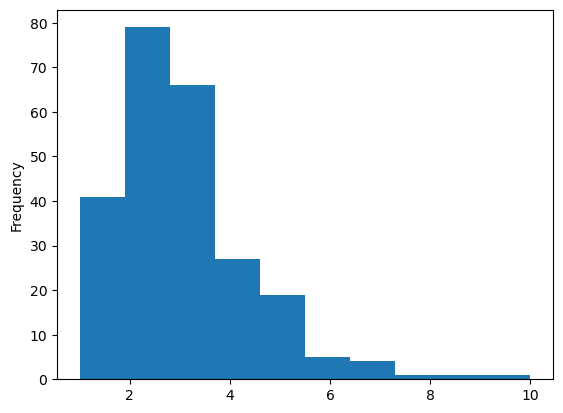

In [19]:
tips.tip.plot(kind='hist')

In [20]:
tips.smoker.value_counts()

smoker
No     151
Yes     93
Name: count, dtype: int64

<Axes: xlabel='smoker'>

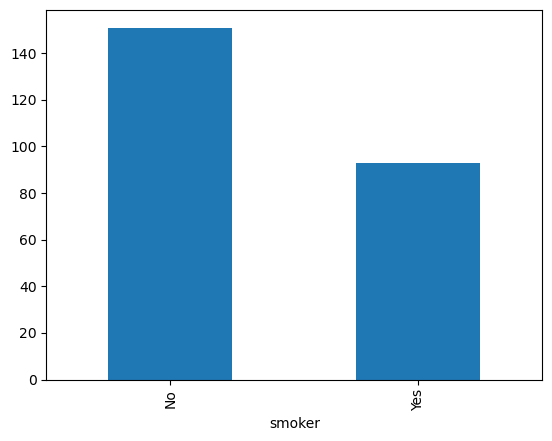

In [21]:
tips.smoker.value_counts().plot(kind='bar')

/var/folders/s7/nhlmv2hx4vg32r27lhnh40t00000gn/T/ipykernel_70694/592652257.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='smoker', data=tips, palette='flare')


<Axes: xlabel='smoker', ylabel='count'>

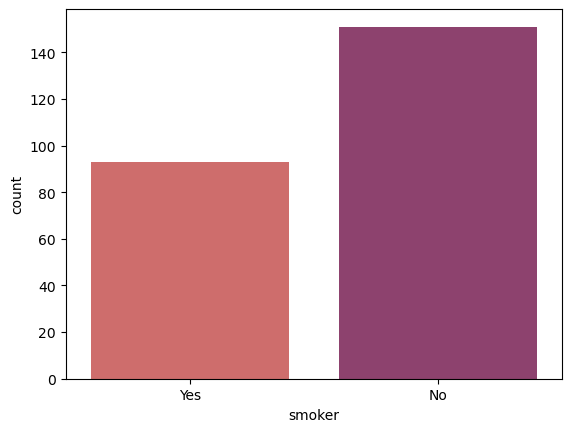

In [22]:
sns.countplot(x='smoker', data=tips, palette='flare')

/var/folders/s7/nhlmv2hx4vg32r27lhnh40t00000gn/T/ipykernel_70694/21351172.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tips.total_bill, kde=True)


<Axes: xlabel='total_bill', ylabel='Density'>

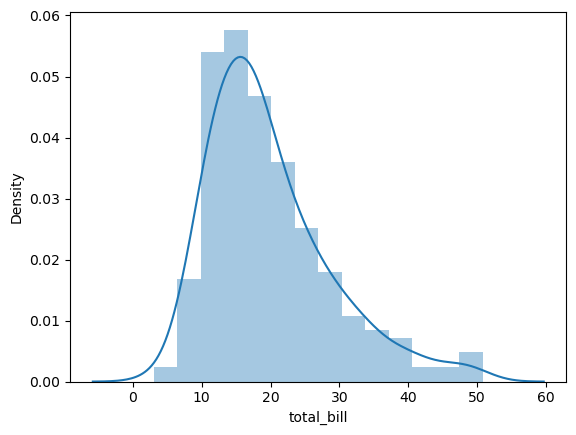

In [26]:
sns.distplot(tips.total_bill, kde=True)

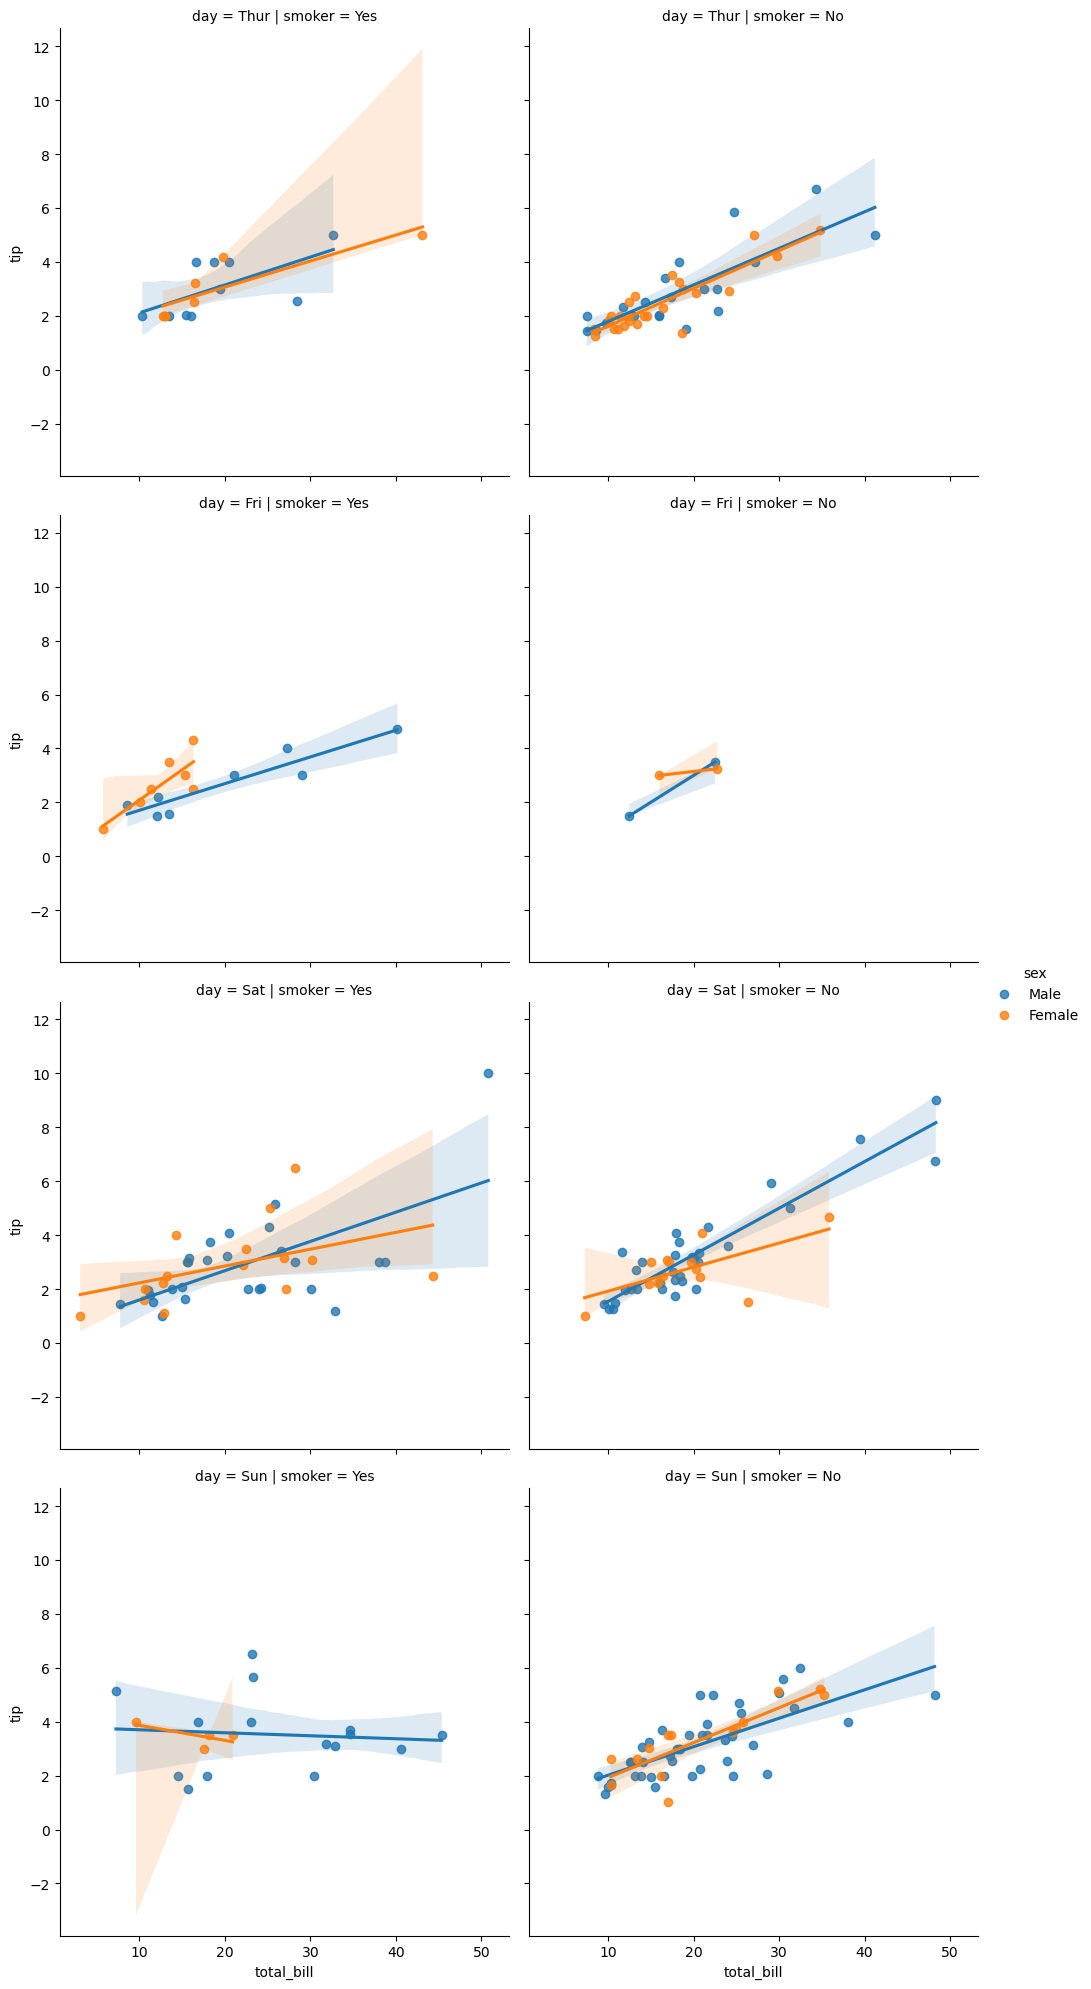

In [30]:
sns.lmplot(x='total_bill', y='tip', data=tips, hue='sex', col='smoker', row='day')

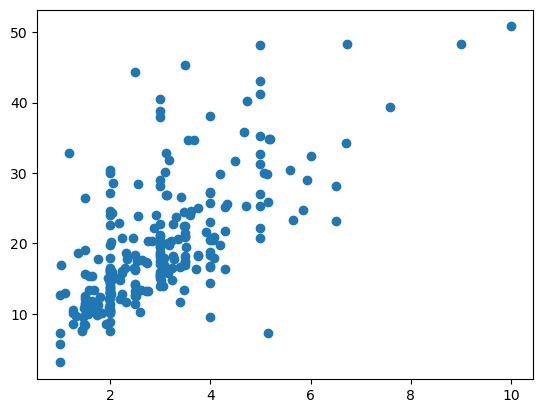

In [31]:
fig, ax = plt.subplots(1,1)
ax.scatter(tips.tip, tips.total_bill)

(array([ 7., 42., 68., 51., 31., 19., 12.,  7.,  3.,  4.]),
 array([ 3.07 ,  7.844, 12.618, 17.392, 22.166, 26.94 , 31.714, 36.488,
        41.262, 46.036, 50.81 ]),
 <BarContainer object of 10 artists>)

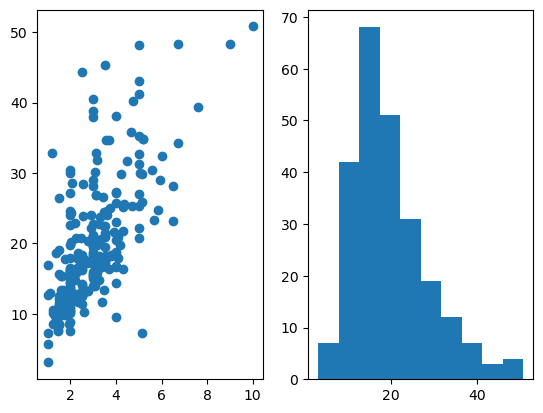

In [32]:
fig, (ax1, ax2) = plt.subplots(1,2)
ax1.scatter(tips.tip, tips.total_bill)
ax2.hist(tips.total_bill)